<blank>

# **SUPPORT VECTOR MACHINE**

**SFRUTTIAMO LE CLASSI DI SCIKIT-LEARN**

## Preparazione dei dati

---

In [1]:
import numpy as np
# Segnale su cui effettuare Train e Validation
g_0_b = np.loadtxt('data/g_0_signal_b.txt')
g_1_b = np.loadtxt('data/g_1_signal_b.txt')
# Segnale su cui effettuare Test Esterno
g_0_a = np.loadtxt('data/g_0_signal_a.txt')
g_1_a = np.loadtxt('data/g_1_signal_a.txt')

Concatenazione gruppi e vettore dei label:

In [2]:
N0, N1 = g_0_b.shape[0], g_1_b.shape[0]
# concateno g_0 e g_1
signal_b = np.vstack((g_0_b, g_1_b))
signal_a = np.vstack((g_0_a, g_1_a))

# vettore delle risposte
labels = np.concatenate((np.zeros(N0), np.ones(N1))) # uguale per A e B

<blank>

## Utilizzo di `GridSearchCV`

---

### Premessa

Con l'oggetto `Pipeline` dividiamo in 3 step il processo, due di pre-processing del segnale, una di effettivo training del modello:
1. `"scaling"`

    Proviamo diversi metodi di scaling:
    - `StandardScaler`: $$X'_\text{Standard}=\frac{X-\mu}{\sigma}$$
    - `MinMaxScaler`: $$X'_\text{MinMax}=\frac{X-X_\text{min}}{X_\text{max}-X_\text{min}}$$
    - `RobustScaler`: $$X'_\text{Robust}=\frac{X-X_\text{mediana}}{IQR}$$

1. `"reduce_dim"`

    Riduzione delle componenti tramite `PCA`; proviamo diversi _numeri di componenti_. 

1. `"classify"`

    Classificazione tramite **Support Vector Machine** (`svm.SVC`); proviamo diversi _kernel_.



`param_grid` è il dizionario che contiene le opzioni dei parametri da fornire a `GridSearchCV`. La sintassi è particolare: con `"__"` si può fare riferimento ad un argomento/membro di una classe fornita in `Pipeline` (e.g. `"nome_step__parametro": valori_da_provare`).

La strategia di cross-validation scelta è `RepeatedStratifiedKFold`:
- **'Stratified'** perché non divide i sample in `n_splits` blocchi statici, ma li costruisce in modo randomico; ci si aspetta maggiore bilanciamento nel numero di positivi e negativi in ciascun fold;
- **'Repeated'** perché ripete per `n_repeats` volte lo split in modi diversi, per diminuire la dipendenza del risultato dal rimescolamento dei dati scelto (i.e. dal seed).

<p align="center">
  <img src="images/StratifiedKFold-scheme.png" alt="Schema k-fold cross-validation">
</p>

`GridSearchCV.fit()` calcolerà l'accuracy $s$ con la strategia di cross-validation scelta su _ciascun split_, per _ciascuna combinazione_ di parametri forniti in `param_grid`. La migliore combinazione di parametri, almeno secondo chi ha scritto questo oggetto, è quella che dà lo _score_ medio $\langle s \rangle$ migliore. $\langle s \rangle$ è calcolato mediando tutti gli $s$ misurati, nel nostro caso sono `n_splits * n_repeats = 5 * 20 = 100`.

Nel dizionario `GridSearchCV.cv_results_` vengono raccolti tutti i risultati del processo di ottimizzazione, per ciascuna combinazione di parametri sono salvati TUTTI gli _score_ ottenuti.

### Codice

Questa GridSearch impiega circa 20 minuti.

In [3]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn import svm

import pickle as pkl
import pandas as pd
import os

# Se il risultato esiste già, non ricalcolare tutto
results_path = "results/SVM/risultati_k_v_C_df.pkl"

if os.path.exists(results_path):
    # Carichiamo il DataFrame
    results_df = pd.read_pickle(results_path)
else:

    rkf = RepeatedStratifiedKFold(n_splits=8, n_repeats=10, random_state=42)

    N_COMPONENTS_OPTIONS = [2, 5, 10, 15, 20]
    C_OPTIONS = [0.00001, 0.0001, 0.001, 0.1, 1, 10]
    KERNEL_OPTIONS = ["linear", "poly", "rbf"] # vince sempre linear ["poly", "rbf", "sigmoid"]
    GAMMA_OPTIONS = ['scale', 'auto', 0.0001, 0.01, 1]

    # 1. Definizione Pipeline #
    pipe = Pipeline([
        # Step 1: Scaling (# NOTE: va inserito uno scaler placeholder)
        ("scaling", StandardScaler()),       
        
        # Step 2: Riduzione dimensionalità (PCA)
        #("reduce_dim", PCA(random_state=42)),
        
        # Step 3: Classificatore
        ("classify", svm.SVC(random_state=42)) 
    ])

    # 2. Definizione griglia dei parametri #
    param_grid = {
        # Per provare diversi oggetti Scaler
        "scaling": [StandardScaler(), MinMaxScaler(), RobustScaler()],
        
        # Per provare parametri specifici di uno step (PCA)
        #"reduce_dim__n_components": N_COMPONENTS_OPTIONS, 
        
        # Per provare parametri del classificatore
        "classify__C": C_OPTIONS,
        
        # Per provare diversi kernel
        "classify__kernel": KERNEL_OPTIONS,
        
        # Gamma dei kernel
        "classify__gamma": GAMMA_OPTIONS,
    }

    # 3. Configurazione GridSearch #
    grid = GridSearchCV(
        pipe, 
        param_grid=param_grid, 
        cv=rkf,
        n_jobs=-1, # «Number of jobs to run in parallel. -1 means using all processors»
        scoring={
        'score': 'accuracy',
        'sensitivity': 'recall'  # recall = sensitivity
        },
        refit='score', # «For multiple metric evaluation, needs to be a str denoting the
        # scorer to use to find the best parameters for refitting the estimator at the end»
        return_train_score=False
        )

    # 4. Training e Validation (su Segnale B) #
    grid.fit(signal_b, labels)

    # 5. Risultati #
    print(f"La miglior configurazione: {grid.best_params_}")
    print(f"Fornisce accuracy in validation: {grid.best_score_:.4f}")
    
    # Conversione dei risultati in DataFrame
    results_df = pd.DataFrame(grid.cv_results_)

    # HACK: Per analizzare in un secondo momento
    # Salvataggio dei risultati in un file pickle
    #results_df.to_pickle(results_path)

La miglior configurazione: {'classify__C': 1e-05, 'classify__gamma': 1, 'classify__kernel': 'poly', 'scaling': MinMaxScaler()}
Fornisce accuracy in validation: 0.7242


<blank>

## Analisi della fase di validation

---

### Classifica degli estimator

In [4]:
# Ciascuna combinazione di parametri è una riga
print(f"Numero totale di configurazioni provate: {results_df.shape[0]}")

# Selezioniamo solo le colonne interessanti per pulire la vista
columns_to_show = [
    'param_scaling', 
    'param_classify__C', 
    'param_classify__kernel',
    'param_classify__gamma',
    'mean_test_score', 
    'std_test_score', 
    'mean_test_sensitivity',
    'rank_test_score'
]

# Ordiniamo per classifica (rank_test_score)
analysis = results_df[columns_to_show].sort_values('rank_test_score')

# Se si ha, è comodo aprire analysis in un viewer tipo Data Wrangler
analysis.head(20)

Numero totale di configurazioni provate: 270


,param_scaling,param_classify__C,param_classify__kernel,param_classify__gamma,mean_test_score,std_test_score,mean_test_sensitivity,rank_test_score
166,MinMaxScaler(),0.10000,poly,0.01,0.724167,0.162701,0.606250,1
121,MinMaxScaler(),0.00100,poly,0.01,0.724167,0.162701,0.606250,1
40,MinMaxScaler(),0.00001,poly,1,0.724167,0.162701,0.606250,1
211,MinMaxScaler(),1.00000,poly,0.01,0.724167,0.162701,0.606250,1
256,MinMaxScaler(),10.00000,poly,0.01,0.724167,0.162701,0.606250,1
184,MinMaxScaler(),1.00000,poly,scale,0.724167,0.162701,0.606250,1
265,MinMaxScaler(),10.00000,poly,1,0.724167,0.162701,0.606250,1
175,MinMaxScaler(),0.10000,poly,1,0.724167,0.162701,0.606250,1
229,MinMaxScaler(),10.00000,poly,scale,0.724167,0.162701,0.606250,1
85,MinMaxScaler(),0.00010,poly,1,0.724167,0.162701,0.606250,1


> 💬 **Commento qualitativo**: \
I parametri più determinanti sembrano quindi essere il `kernel` (linear) e lo scaler. `MinMaxScaler` tutti i valori di `C` restituisce risultati praticamente identici. Con `RobustScaler` i modelli hanno accuracy simile ma sensitivity molto più alta (4%), teniamo questi parametri.

### Analisi quantitativa

TypeError: 'Axes' object is not subscriptable

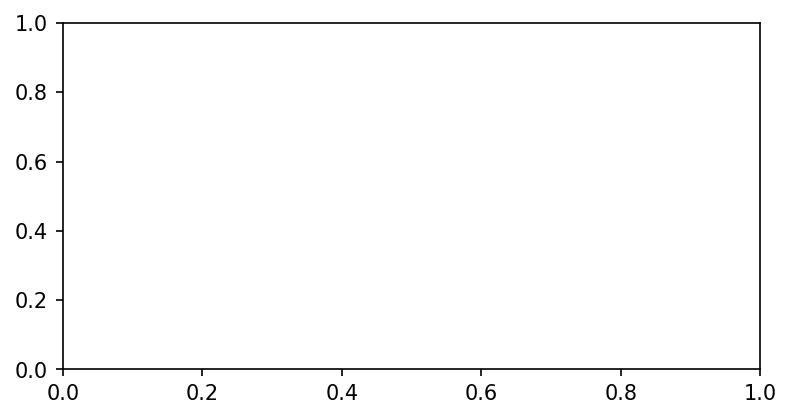

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convertiamo gli oggetti scaler in stringhe (es. da <StandardScaler()> a "StandardScaler")
if 'param_scaling' in results_df.columns:
    results_df['param_scaling'] = results_df['param_scaling'].apply(lambda x: type(x).__name__ if x is not None else "None")

# 2. Ora la lista dei parametri funzionerà correttamente
params_to_check = [col for col in results_df.columns if 'param_classify__' in col]
if 'param_scaling' in results_df.columns:
    params_to_check.append('param_scaling') # Usiamo il nome della colonna, non i dati

# Creiamo una figura con vari subplot
fig, axes = plt.subplots(len(params_to_check), 1, figsize=(6, 3 * len(params_to_check)), dpi=150)

for i, param in enumerate(params_to_check):
    # Calcoliamo la media dell'accuracy per ogni valore del parametro
    stats = results_df.groupby(param)['mean_test_score'].mean().sort_values(ascending=False)
    
    # Plotting
    sns.barplot(x=stats.index, y=stats.values, ax=axes[i], palette="bright", legend=False, hue=stats.index)
    axes[i].set_title(f"Impatto di {param.replace('param_classify__', '')}")
    axes[i].set_ylabel("Mean Accuracy")
    axes[i].set_ylim(results_df['mean_test_score'].min() - 0.02, results_df['mean_test_score'].max() + 0.02)
    
    # Stampiamo i valori testuali per precisione
    print(10*"----")
    print(stats)

plt.tight_layout()
plt.show()

## Ripetizione GridSearch CON PCA fissando scaler e kernel

In [ ]:
rkf = RepeatedStratifiedKFold(n_splits=8, n_repeats=10, random_state=42)

N_COMPONENTS_OPTIONS = [2, 7, 10, 14, 19, 27, None]
C_OPTIONS = [0.0001, 0.001, 0.1, 1, 10, 100]

# 1. Definizione Pipeline #
pipe = Pipeline([
    # Step 1: Scaling
    ("scaling", RobustScaler()),       
    
    # Step 2: Riduzione dimensionalità (PCA)
    ("reduce_dim", PCA(random_state=42)),
    
    # Step 3: Classificatore
    ("classify", svm.SVC(
        kernel='linear',
        random_state=42
        )) 
])

# 2. Definizione griglia dei parametri #
param_grid = {
    # Per provare parametri specifici di uno step (PCA)
    "reduce_dim__n_components": N_COMPONENTS_OPTIONS, 
    
    # Per provare parametri del classificatore
    "classify__C": C_OPTIONS,
}

# 3. Configurazione GridSearch #
grid = GridSearchCV(
    pipe, 
    param_grid=param_grid, 
    cv=rkf,
    n_jobs=-1, # «Number of jobs to run in parallel. -1 means using all processors»
    scoring={
    'score': 'accuracy',
    'sensitivity': 'recall'  # recall = sensitivity
    },
    refit='score', # «For multiple metric evaluation, needs to be a str denoting the
    # scorer to use to find the best parameters for refitting the estimator at the end»
    return_train_score=False
    )

# 4. Training e Validation (su Segnale B) #
grid.fit(signal_b, labels)

# 5. Risultati #
print(f"La miglior configurazione: {grid.best_params_}")
print(f"Fornisce accuracy in validation: {grid.best_score_:.4f}")

# Conversione dei risultati in DataFrame
results_df_pca = pd.DataFrame(grid.cv_results_)

In [21]:
# Ciascuna combinazione di parametri è una riga
print(f"Numero totale di configurazioni provate: {results_df_pca.shape[0]}")

# Selezioniamo solo le colonne interessanti per pulire la vista
columns_to_show = [
    'param_reduce_dim__n_components',
    #'param_classify__C', 
    'mean_test_score', 
    'std_test_score', 
    'mean_test_sensitivity',
    'rank_test_score'
]

# Ordiniamo per classifica (rank_test_score)
analysis = results_df_pca[columns_to_show].sort_values('rank_test_score')

# Se si ha, è comodo aprire analysis in un viewer tipo Data Wrangler
analysis.head(20)

Numero totale di configurazioni provate: 48


,param_reduce_dim__n_components,mean_test_score,std_test_score,mean_test_sensitivity,rank_test_score
23,None,0.721250,0.198833,0.645833,1
39,None,0.721250,0.198833,0.645833,1
31,None,0.721250,0.198833,0.645833,1
15,None,0.721250,0.198833,0.645833,1
47,None,0.721250,0.198833,0.645833,1
7,None,0.677500,0.214137,0.593750,6
2,10,0.660833,0.192770,0.541667,7
3,14,0.656250,0.216897,0.504167,8
25,7,0.654167,0.196947,0.608333,9
42,10,0.653750,0.185704,0.660417,10


### heatmaps **accuracy** e **sensitivity** PCA v C

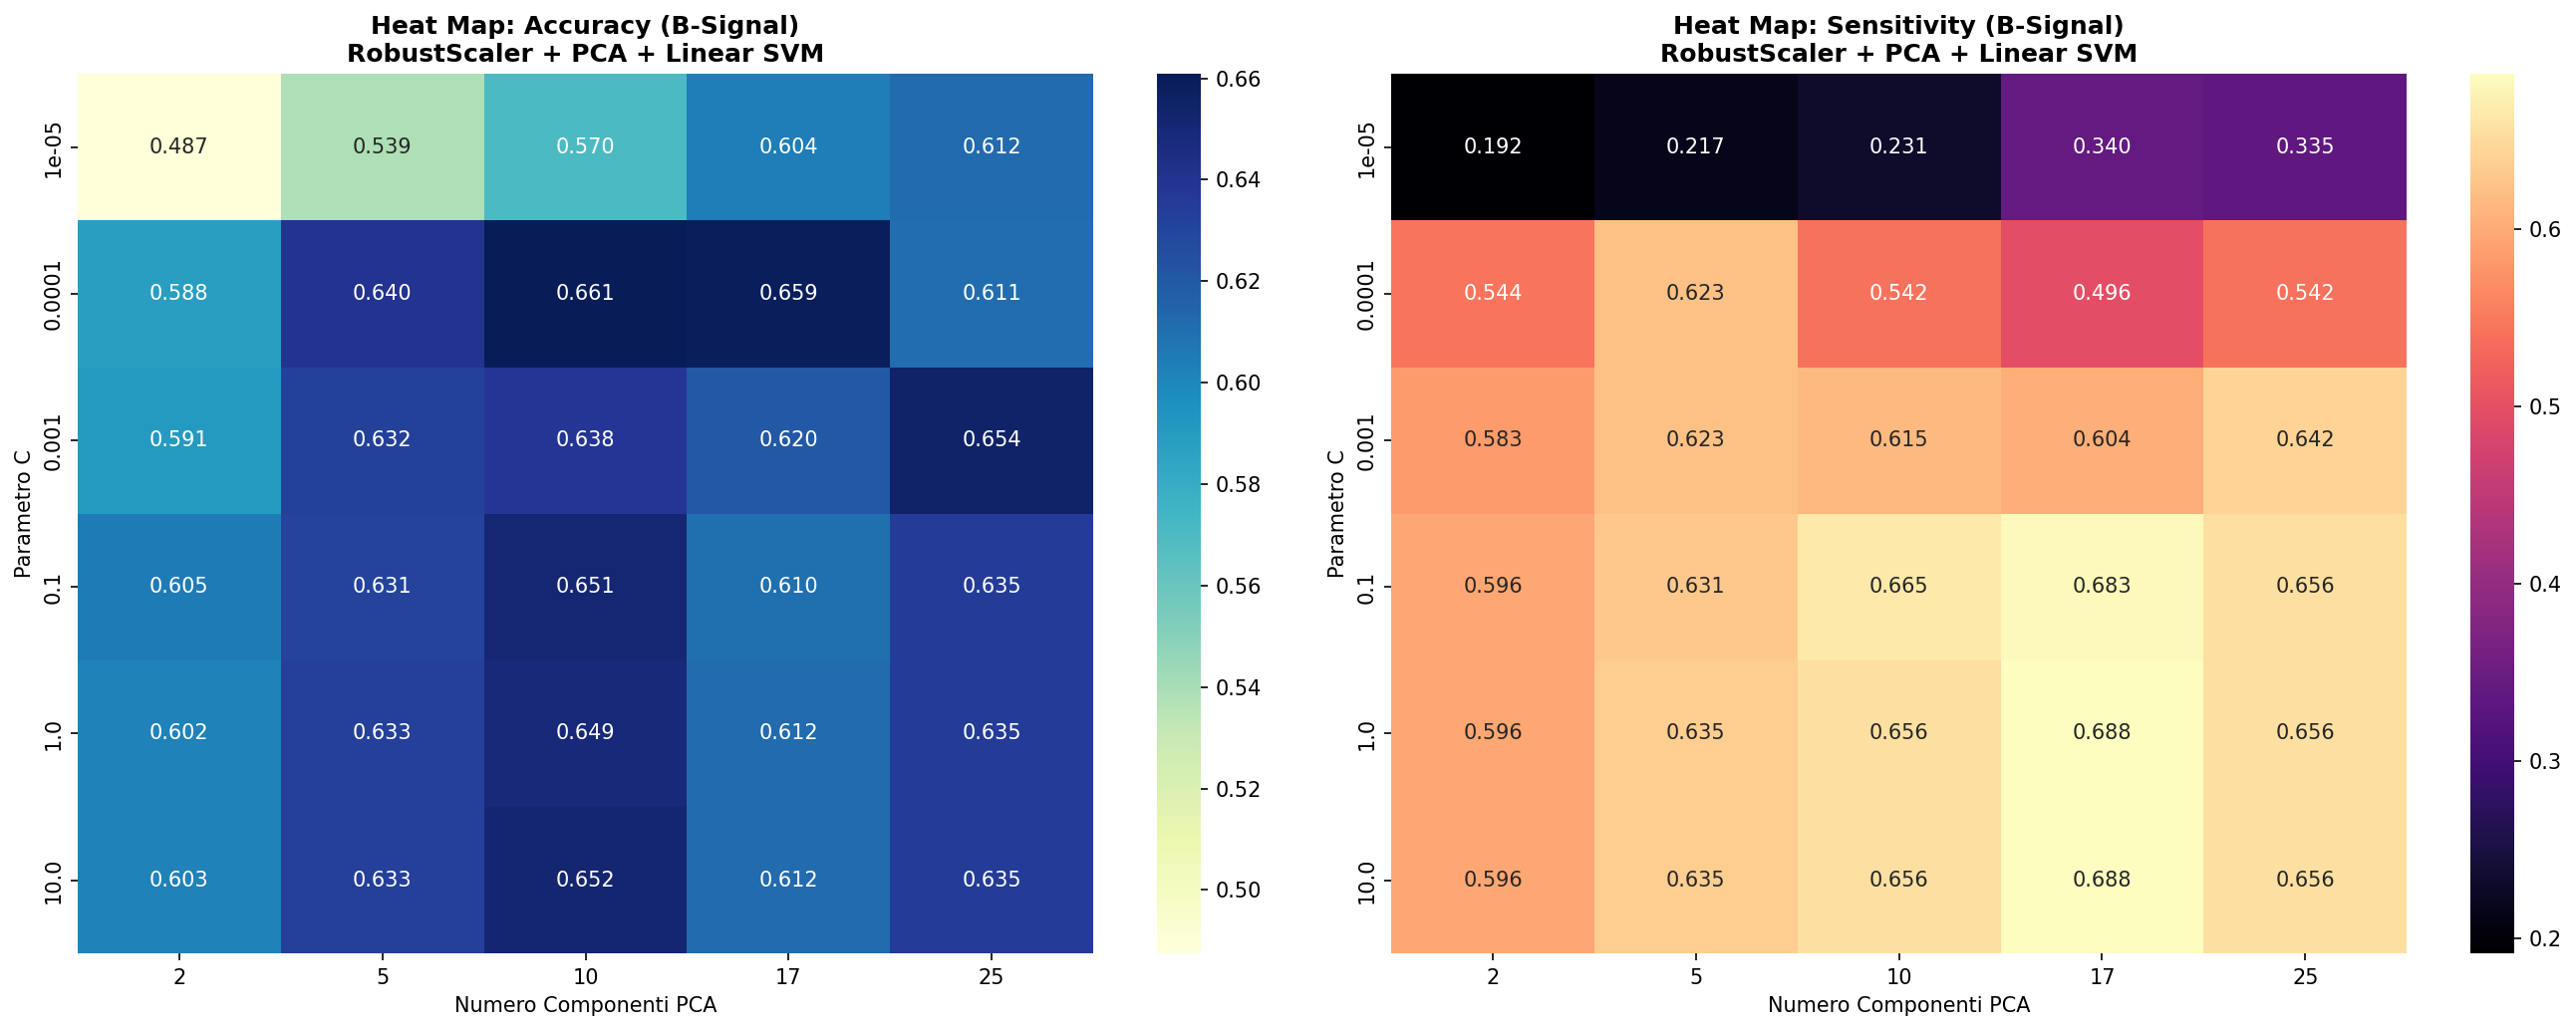

In [16]:
# 1. Preparazione dei dati: Pivot delle tabelle
# Trasformiamo il DataFrame in matrici (Indice = C, Colonne = n_components)
pivot_acc = results_df.pivot(index='param_classify__C', 
                                 columns='param_reduce_dim__n_components', 
                                 values='mean_test_score')

pivot_sens = results_df.pivot(index='param_classify__C', 
                                  columns='param_reduce_dim__n_components', 
                                  values='mean_test_sensitivity')

# 2. Creazione della figura
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=150)

# --- Heatmap Accuracy ---
sns.heatmap(pivot_acc, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title('Heat Map: Accuracy (B-Signal)\nRobustScaler + PCA + Linear SVM', fontweight='bold')
axes[0].set_xlabel('Numero Componenti PCA')
axes[0].set_ylabel('Parametro C')

# --- Heatmap Sensitivity ---
sns.heatmap(pivot_sens, annot=True, fmt=".3f", cmap="magma", ax=axes[1])
axes[1].set_title('Heat Map: Sensitivity (B-Signal)\nRobustScaler + PCA + Linear SVM', fontweight='bold')
axes[1].set_xlabel('Numero Componenti PCA')
axes[1].set_ylabel('Parametro C')

plt.tight_layout()
plt.show()

La PCA non sembra avere un particolare effetto benefico.

## Test

---

### Score dei migliori 10 modelli

In [6]:
print("Accuracy dei modelli in top 10 sul segnale A")
for i in range(10):
    # il kernel migliore è sempre linear
    scaler = analysis.iloc[i]["param_scaling"]
    #n_comp = analysis.iloc[i]["param_reduce_dim__n_components"]
    C_val  = analysis.iloc[i]["param_classify__C"]
    
    top_ten_pipe = Pipeline([
    ("scaling", scaler),       
    #("reduce_dim", PCA(n_components=n_comp, random_state=42)),
    ("classify", svm.SVC(C=C_val, kernel="linear", random_state=42)) 
    ])

    top_ten_pipe.fit(signal_b, labels)
    acc = top_ten_pipe.score(signal_a, labels)

    print(f"{i+1}. acc = {acc:.4f}")


Accuracy dei modelli in top 10 sul segnale A
1. acc = 0.2273
2. acc = 0.3182
3. acc = 0.3409
4. acc = 0.2273
5. acc = 0.2273
6. acc = 0.2273
7. acc = 0.2273
8. acc = 0.2273
9. acc = 0.2273
10. acc = 0.3409
